# ASSIGNMENT 4: Linear and logistic regression

## Business understanding (Sandra)

## Data understanding (Anni)

In [51]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
real_estate_valuation = fetch_ucirepo(id=477) 
  
# data (as pandas dataframes) 
X = real_estate_valuation.data.features 
y = real_estate_valuation.data.targets['Y house price of unit area']

In [52]:
X

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245
...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0,24.94155,121.50381
410,2012.667,5.6,90.45606,9,24.97433,121.54310
411,2013.250,18.8,390.96960,7,24.97923,121.53986
412,2013.000,8.1,104.81010,5,24.96674,121.54067


In [53]:
y

0      37.9
1      42.2
2      47.3
3      54.8
4      43.1
       ... 
409    15.4
410    50.0
411    40.6
412    52.5
413    63.9
Name: Y house price of unit area, Length: 414, dtype: float64

## Data preperation (Anni)

In [54]:
for col in X.columns.values:
    if X[col].dtype != 'float64':
        X[col] = X[col].astype(dtype='float64')

X

C:\Users\riikk\AppData\Local\Temp\ipykernel_22552\1484296808.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype(dtype='float64')


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10.0,24.98298,121.54024
1,2012.917,19.5,306.59470,9.0,24.98034,121.53951
2,2013.583,13.3,561.98450,5.0,24.98746,121.54391
3,2013.500,13.3,561.98450,5.0,24.98746,121.54391
4,2012.833,5.0,390.56840,5.0,24.97937,121.54245
...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0.0,24.94155,121.50381
410,2012.667,5.6,90.45606,9.0,24.97433,121.54310
411,2013.250,18.8,390.96960,7.0,24.97923,121.53986
412,2013.000,8.1,104.81010,5.0,24.96674,121.54067


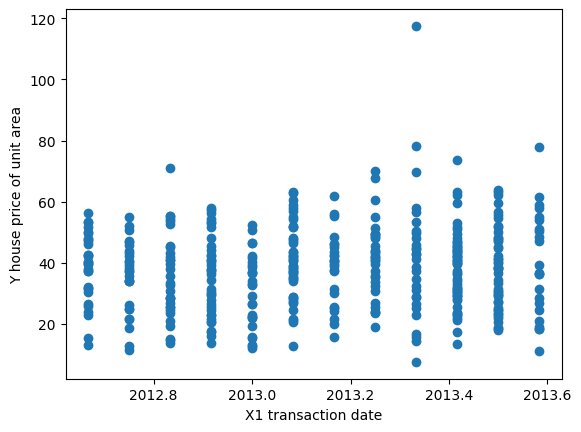

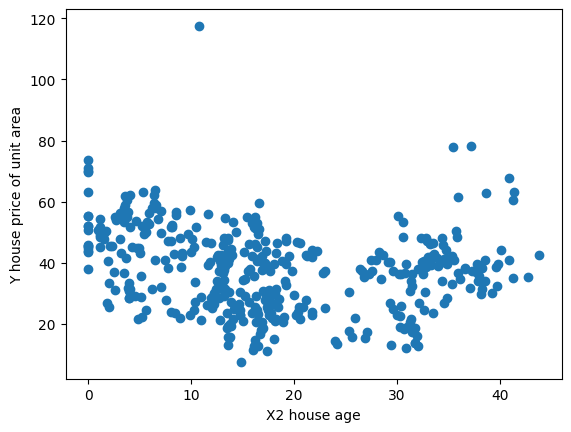

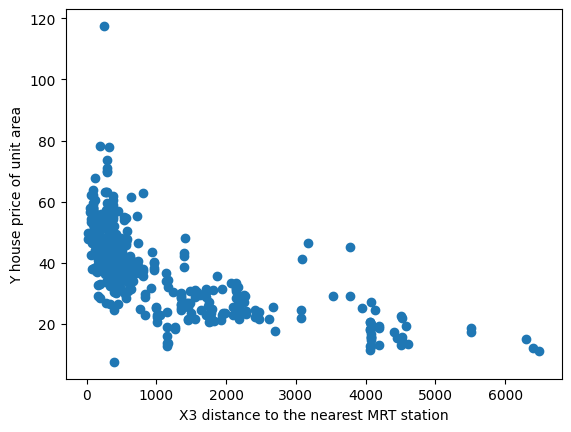

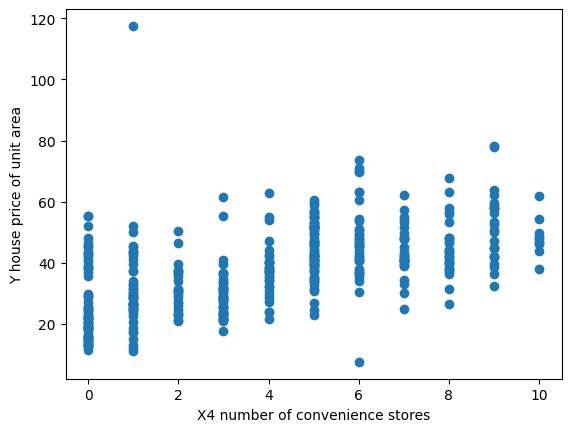

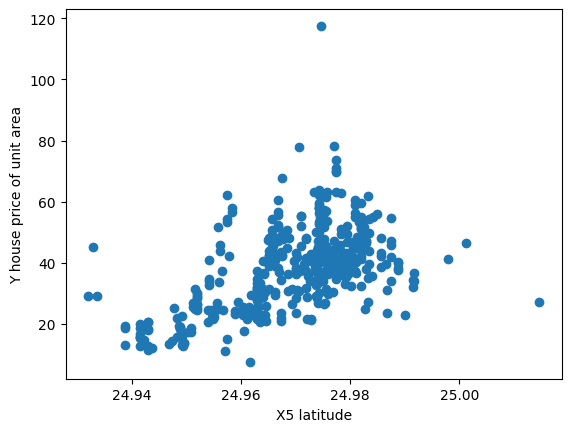

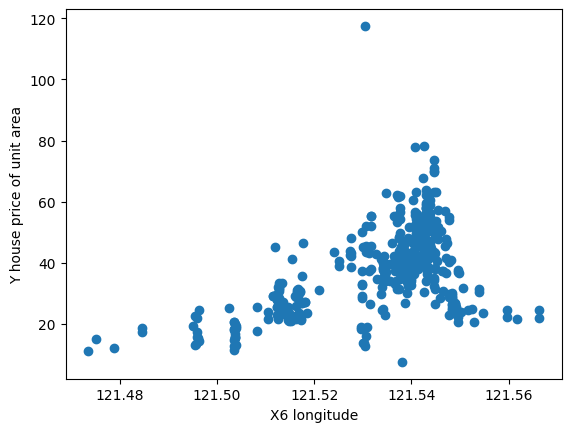

In [55]:
import matplotlib.pyplot as plt

for col in X.columns:
    plt.scatter(X[col], y)
    plt.xlabel(col)
    plt.ylabel('Y house price of unit area')
    plt.show()

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=123)

In [57]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [58]:
X_train

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,0.945014,0.008392,-0.067556,-1.392631,-0.524868,1.017443
1,-0.246786,-0.468570,0.219898,-1.049182,-1.415896,0.970115
2,1.241180,-1.153661,0.840932,-0.362284,-0.529724,-1.336628
3,0.052948,-0.095672,0.951876,-0.362284,-0.864770,-1.288004
4,-0.839118,-1.327102,0.295361,-1.049182,-1.483876,1.007718
...,...,...,...,...,...,...
305,1.241180,-1.153661,0.840932,-0.362284,-0.529724,-1.336628
306,0.945014,-0.078328,-0.624844,0.324615,1.011162,0.649842
307,-0.542952,-0.381849,-0.705185,-1.049182,0.351592,-0.236419
308,-0.542952,-0.087000,1.931310,-1.392631,-3.032046,-1.133702


In [59]:
X_test

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,-0.839118,1.517327,-0.703168,1.354963,0.609755,0.626502
1,0.645280,-0.078328,-0.624844,0.324615,1.011162,0.649842
2,0.052948,-0.355833,-0.261372,-0.705733,0.337834,1.040782
3,-1.138852,-0.399193,-0.718875,-1.049182,0.337834,-0.234474
4,1.241180,-1.049596,-0.544975,0.324615,0.795891,0.583064
...,...,...,...,...,...,...
99,1.241180,-1.144989,-0.606249,0.324615,-1.102701,0.395698
100,1.241180,-0.312473,-0.655369,1.011513,-0.281272,0.616777
101,-1.731183,1.491311,-0.361242,1.011513,0.792654,0.192124
102,-1.731183,-0.156376,-0.209415,-0.018834,0.754618,0.076722


## Modeling

Two different regression models will be created in the modeling phase. The models do slightly different things meaning that they are not meant to be compared on their performance. The Linear Regression model will predict the house price of unit area for a house based on its feature values while the Logical Regression model will predict whether the house price of unit area for a house is below or above the average based on the provided information. The models will be individually validated and analysed.

## Linear regression model (Riikka)

The Linear Regression model is built with the `LinearRegression` class that `Scikit-learn` library provides. Since split validation is used as the validation method, the model is trained with training set, `X_train` containing the features and `y_train` containing the target values, using the models `fit` method.

In [60]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

From the trained model the intercept ($\beta_0$) and coefficient values ($\beta_1$, $\beta_2$, $\beta_3$, $\beta_4$, $\beta_5$, $\beta_6$) for the linear regression equation can be inspected. These values were determined to provide the best fit with the training data meaning they minimize the mean squared error or `MSE` value compared to other combinations.

In [61]:
b0 = model.intercept_ # note the underscore!
b1 = model.coef_ # returns a list containing a single element

print("Intercept: %.2f" % b0)

for b, name in zip(b1, model.feature_names_in_):
    print(name + ", Coefficient: %.4f" % b)

Intercept: 38.06
X1 transaction date, Coefficient: 1.3819
X2 house age, Coefficient: -3.1150
X3 distance to the nearest MRT station, Coefficient: -6.0160
X4 number of convenience stores, Coefficient: 3.1183
X5 latitude, Coefficient: 2.7696
X6 longitude, Coefficient: -0.4677


The coefficient values provide information on how the different features affect the prediction. Negative values decrease the prediction while positive values increase the prediction. From the estimated values we can see that the X3 feature `distance to the nearest MRT station` and the X4 `number of convenience stores` feature have the biggest impact on the prediction, but they have an opposite effect, X3 decreases and X4 increases prediction or the `house price of unit area`.

This phase also highlights the importance of standardization of the data. Without standardization the feature values would all be on different scales (e.g. X4 distance to the nearest MRT station vs. X3 number of convenience stores) and the model would conclude that the feature which values are on a higher scale has a bigger impact on the prediction only because the value is larger. With standardization all the features are on the same scale and the model can estimate the importance of the features properly.

Feature importance can be also estimated with permutation importance. `Scikit-learn` provides a function, `permutation_importance` that estimates the feature importances. The `n_repeats` parameter specifies how many times the permutation process is repeated. The permutation importance was estimated on the train dataset. The following graph visualizes the permutation importance.

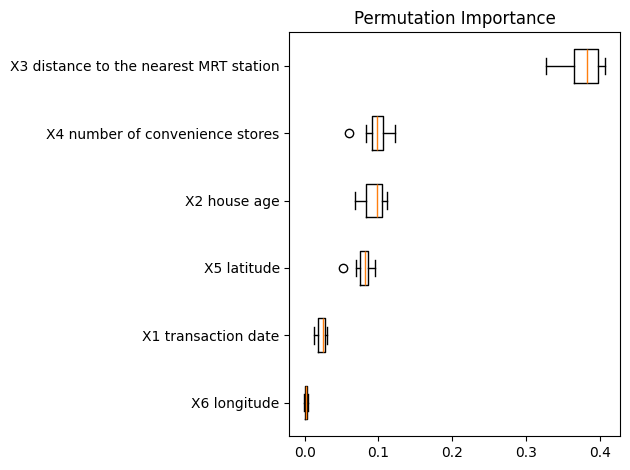

In [62]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=0, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots()
ax.boxplot(result.importances[sorted_idx].T, vert=False, tick_labels=X.columns[sorted_idx])
ax.set_title("Permutation Importance")
fig.tight_layout()
plt.show()

Once again we can see that the X3 feature `distance to the nearest MRT station` and the X4 `number of convenience stores` feature have the biggest impact on the prediction

The following graphs visualize the linear trendlines for each feature on the training data. We also noticed that without standardization the graphs were illegible. The intercept value was really high and the coefficient values were all on different scales. These made the datapoints in the graphs concentrate on the top and the trendline was on the bottom. There was no way to analyse the graphs.

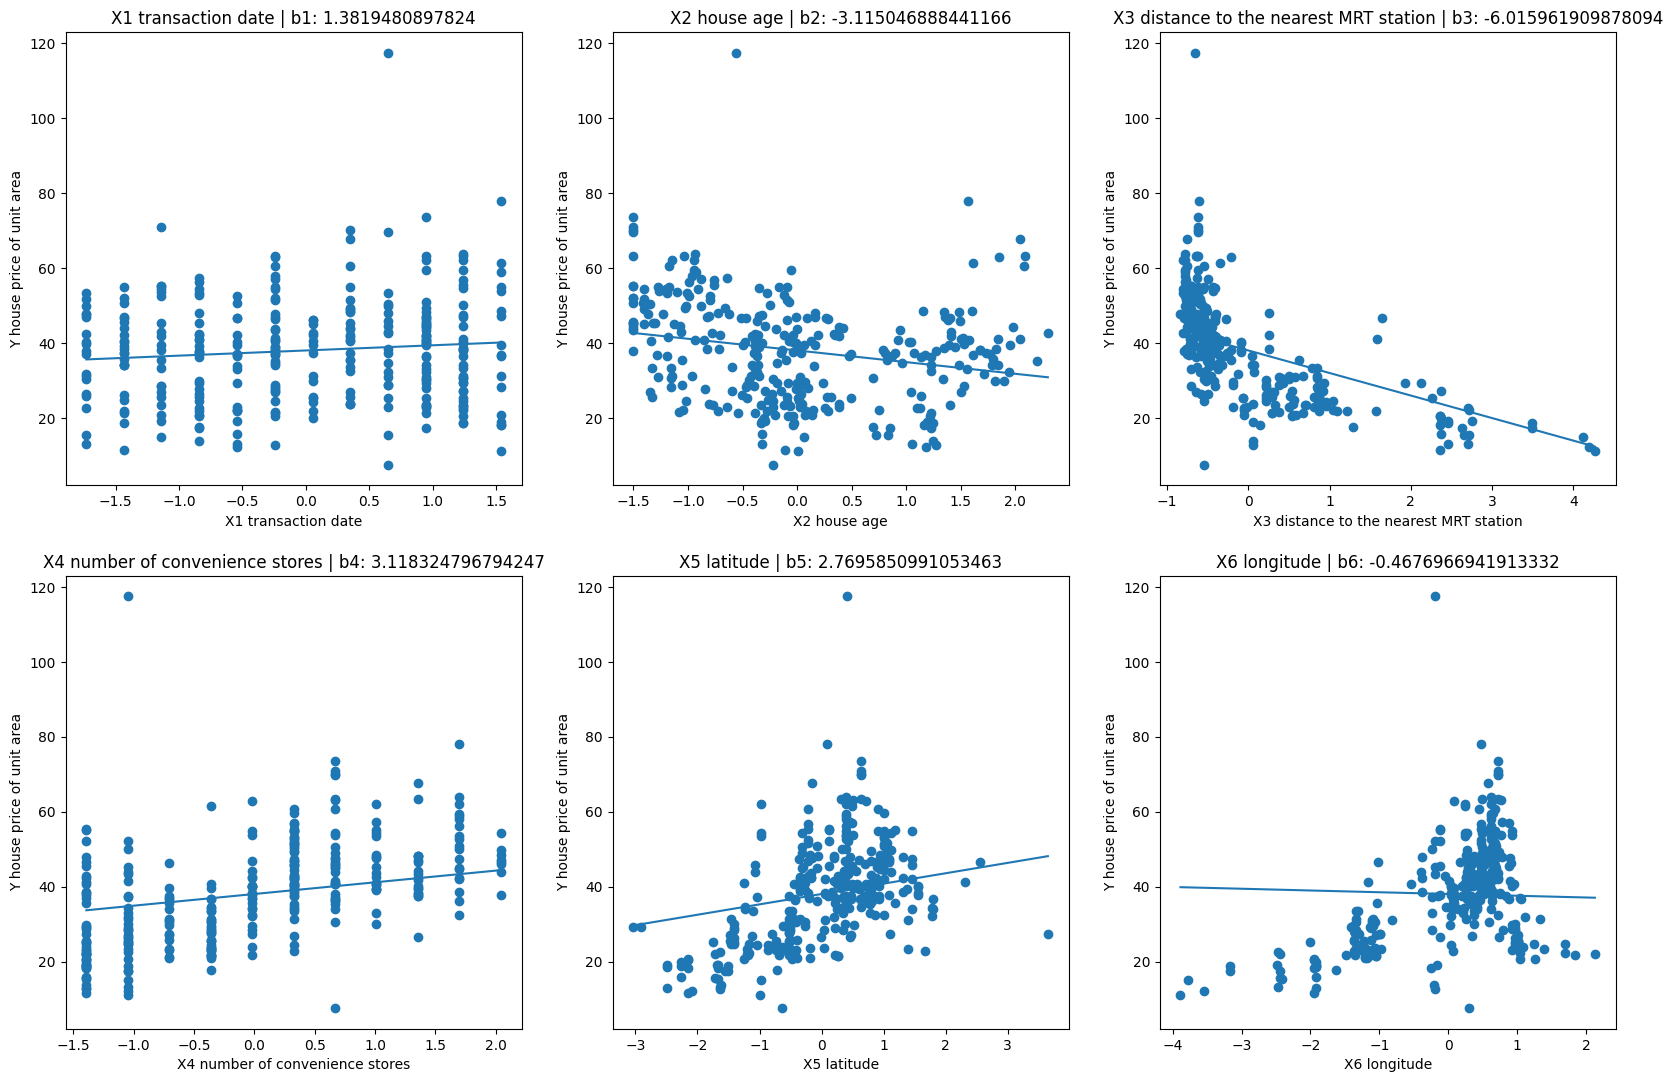

In [63]:
import numpy as np

count = 1
plt.figure(figsize=(20, 20))
for col, b in zip(X_train.columns, b1):
    plt.subplot(3, 3, count)
    xs = np.linspace(X_train[col].min(), X_train[col].max())
    ys = b0 + b * xs
    plt.plot(xs, ys)
    plt.scatter(X_train[col], y_train)
    plt.xlabel(col)
    plt.ylabel('Y house price of unit area')
    plt.title("" + str(col) + " | b" + str(count) + ": " + str(b))
    count+=1
    
plt.show()

All the trendlines are either linearly growing or linearly decaying. Linearly growing trendlines indicate that the house price of unit area will increase with higher feature values and linearly decaying trendlines indicate that the house price of unit area will decrease with higher feature values. We can see that higher values in X4 `number of convenience stores` and X5 `latitude` features seem to indicated higher house price of unit area while higher values in X2 `house age` and X3 `distance to the nearest MRT station` features seem to indicate lower house price of unit area.

The model is validated and tested using the test set, `X_test` containing the features and `y_test` containing the target values. The `predict` method of the model predicts the value for the sample based on the features.

The validation metric used to evaluate the performance of the linear regression model is mean absolute error or `MAE`. The MAE score measures how much the predicted values differ from the actual values on average. `Scikit-learn` library provides the `mean_absolute_error` function for calculating the MEA score. It takes the actual target values and the predicted values as parameters.

In [64]:
from sklearn.metrics import mean_absolute_error

preds = model.predict(X_test)
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, preds))

Mean absolute error: 5.14


The MEA score for the model is 5.14. This means that the predicted house price of unit area values differ from the actual values by 5.14 (10000 Taiwan Dollars / Ping) or by 54000 Taiwan Dollars per ping. 

Residuals can also be used to evaluate the linear regression models suitability to make predictions from the provided data. The residuals are the difference between the predicted values and true values. The grap below visualizes the residuals.

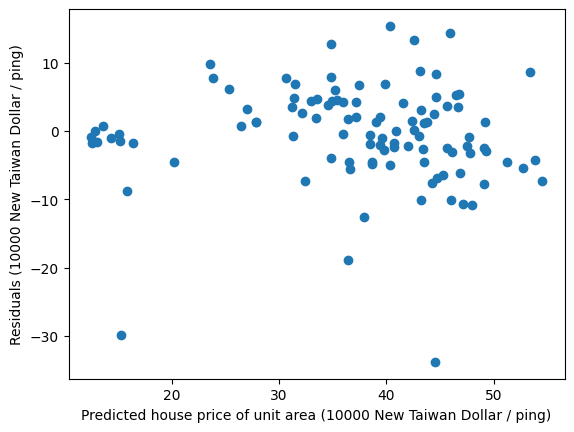

In [65]:
plt.scatter(preds, preds - y_test)
plt.xlabel('Predicted house price of unit area (10000 New Taiwan Dollar / ping)')
plt.ylabel('Residuals (10000 New Taiwan Dollar / ping)')
plt.show()

The graph indicates that linear regression is suitable for this dataset though not a perfect fit. Most of the residuals are distributed around the horizontal zero line and there is no noticeable trend in the variance but there are some outliers so variance cannot be considered to be a constant either. It is worth noting that the original dataset was fairly small and contained some samples that noticeably differed from the majority of the data, making it hard for the trained model to make correct predictions for these samples if they were in the test set resulting in the large residuals for these samples during validation.

## Logistic regression model (Nur)

In [66]:
import numpy as np

mean = y_train.mean()
print(mean)

y_train_b = (y_train > mean).astype(int)
y_test_b = (y_test > mean).astype(int)

38.0641935483871


In [67]:
from sklearn.linear_model import LogisticRegression

reg_model = LogisticRegression(solver='lbfgs')
reg_model.fit(X_train, y_train_b)

print("Coefficients: ", reg_model.coef_)
print("Intercept: ", reg_model.intercept_)

Coefficients:  [[ 0.34245483 -0.7294161  -2.42400942  0.62318646  1.07447641  0.26783573]]
Intercept:  [-0.77409722]


Accuracy: 0.81
Confusion Matrix:
 [[38 10]
 [10 46]]


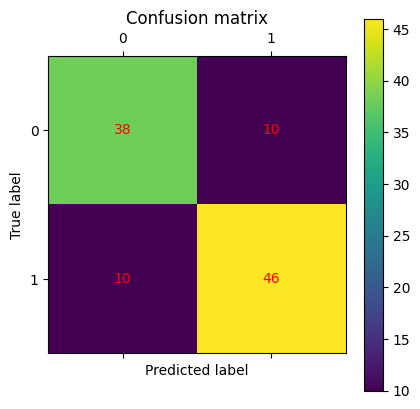

In [68]:
from sklearn.metrics import accuracy_score

preds = reg_model.predict(X_test)

cm = confusion_matrix(y_test_b, preds)
accuracy = accuracy_score(y_test_b, preds)

print("Accuracy: %0.2f" % accuracy)
print("Confusion Matrix:\n", cm)

# visualize confusion matrix
plt.matshow(cm)
plt.title('Confusion matrix')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')

# include counts
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red')
plt.show()

0 alle keskiarvon (mean), 1 yli keskiarvon (mean) - hinta

The model seems to predict the outcome quite well, with an accuracy of 0.81.

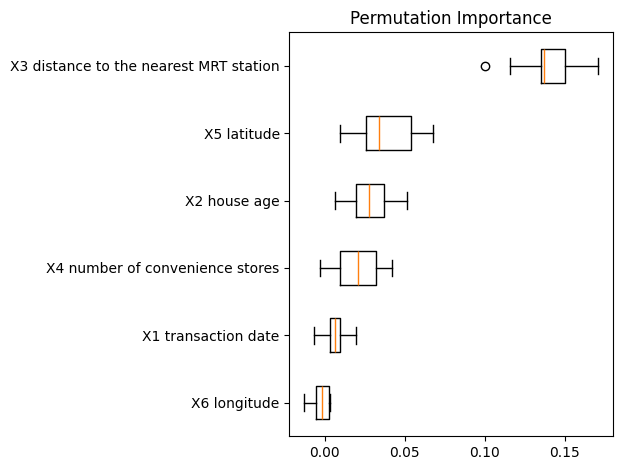

In [69]:
from sklearn.inspection import permutation_importance

result = permutation_importance(reg_model, X_train, y_train_b, n_repeats=10, scoring="accuracy", random_state=0, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots()
ax.boxplot(result.importances[sorted_idx].T, vert=False, tick_labels=X.columns[sorted_idx])
ax.set_title("Permutation Importance")
fig.tight_layout()
plt.show()

tärkein on X3, vähiten tärkein on X6. selitä pikaisesti tulokset, älä mene syvälle

## Evaluation (Sandra)

## Deployment (Sandra)